# Local Differential Privacy Training

Dataset: **Bank Marketing**

This notebook corresponds to **Section 5 "Private-data workflow (Local
Differential Privacy)"** of the paper.

Local DP perturbs each user's record on the client side using the Direct
Encoding mechanism (paper Section 5.2). Because Direct Encoding operates on
categorical data, the numerical features in `bank-cleaned.csv` are discretized
into ordinal categories (paper Section 5.1) before being mapped to integer
indices and perturbed.

> **Environment**: run this notebook in the `.ldp` virtual environment
> (TensorFlow 2.18, Keras 3, pure-ldp 1.2; see `requirements/ldp.txt`).

In [1]:
import random
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix,
)
from imblearn.combine import SMOTEENN
from boruta import BorutaPy
import xgboost as xgb

import tensorflow as tf
from keras import Sequential
from keras.src.layers import Dense, Dropout
from keras.src.optimizers import Adam
from keras.src.callbacks import EarlyStopping

from pure_ldp.frequency_oracles.direct_encoding import DEClient

# Paths
ROOT = Path.cwd().resolve()
DATA_PROCESSED = ROOT.parent / "data" / "processed"
FIG_DIR = ROOT.parent / "figures"
RES_DIR = ROOT.parent / "results"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Experiment configuration
METHOD = "Direct_Encoding"
EPSILONS = [5, 3, 2, 1, 0.5, 0.1]
N_ITERATIONS = 10


In [2]:
df = pd.read_csv(DATA_PROCESSED / "bank-cleaned.csv")
X = df.drop(columns=["y"])
y = df["y"]


## Helper functions

In [3]:
# Map binary categorical variables to {0, 1} and months to {1..12}
def map_binary_columns(df):
    df["default"] = df["default"].map({"no": 0, "yes": 1})
    df["housing"] = df["housing"].map({"no": 0, "yes": 1})
    df["loan"]    = df["loan"].map({"no": 0, "yes": 1})
    df["month"]   = df["month"].map({
        "jan": 1, "feb": 2, "mar": 3, "apr": 4,
        "may": 5, "jun": 6, "jul": 7, "aug": 8,
        "sep": 9, "oct": 10, "nov": 11, "dec": 12,
    })
    return df


In [4]:
# Discretize numerical variables into ordinal categories (paper §5.1).
# Bin edges and labels are kept verbatim from the published configuration.
def convert_numerics_to_categories(df):
    bins = {
        "age":      ([18, 30, 40, 50, 60, 95],          ["18-30", "31-40", "41-50", "51-60", "61+"]),
        "balance":  ([-8019, 0, 72, 448, 1428, 102127], ["negative", "0-72", "73-448", "449-1428", "1429+"]),
        "day":      ([1, 7, 14, 21, 31],                ["1-7", "8-14", "15-21", "22-31"]),
        "duration": ([0, 103, 180, 319, 4918],          ["0-103", "104-180", "181-319", "320+"]),
        "campaign": ([1, 2, 3, 10, 63],                 ["1", "2-3", "4-10", "11+"]),
        "pdays":    ([-1, 0, 30, 90, 871],              ["no_contact", "0-30", "31-90", "91+"]),
        "previous": ([0, 1, 2, 5, 275],                 ["0", "1-2", "3-5", "6+"]),
    }
    for col, (edges, labels) in bins.items():
        df[col] = pd.cut(df[col], bins=edges, labels=labels, include_lowest=True)
    return df


In [5]:
# Map each categorical value to an integer index in {1, ..., d}.
# DEClient expects 1-indexed inputs, so the index space starts at 1.
def map_categorical_columns(df, categorical_columns):
    mappings = {}
    for col in categorical_columns:
        df[col] = df[col].astype(str).replace("nan", pd.NA)
        unique_values = sorted(df[col].dropna().unique())
        mappings[col] = {value: idx + 1 for idx, value in enumerate(unique_values)}
        df[col] = df[col].map(mappings[col])
    return df, mappings


In [6]:
# Apply Direct Encoding perturbation column-by-column with privacy budget epsilon
def apply_de(df, epsilon, categorical_columns, cat_mappings):
    df_de = df.copy()
    for col in categorical_columns:
        d = len(cat_mappings[col])
        de = DEClient(epsilon=epsilon, d=d)
        df_de[col] = df_de[col].apply(lambda x: de.privatise(x) if pd.notna(x) else x)
    return df_de


In [7]:
# Feedforward neural network with configurable depth and width
def build_model(input_shape, learning_rate, dropout_rate, units, hidden_layers):
    model = Sequential()
    model.add(Dense(units, activation="relu", input_shape=(input_shape,)))
    model.add(Dropout(dropout_rate))
    for _ in range(hidden_layers - 1):
        model.add(Dense(units, activation="relu"))
        model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation="sigmoid"))
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["AUC"],
    )
    return model


In [8]:
# One-hot encode, train/test split, SMOTEENN resample, and Boruta feature selection
def process_data(X, y, categorical_columns, cat_mappings, apply_DE=False, epsilon=None):
    x = X.copy()
    if apply_DE and epsilon is not None:
        x = apply_de(x, epsilon, categorical_columns, cat_mappings)

    x = pd.get_dummies(x, columns=categorical_columns, drop_first=True, dtype="int64")
    X_train, X_test, y_train, y_test = train_test_split(
        x, y, test_size=0.3, random_state=SEED,
    )

    X_train, y_train = SMOTEENN(random_state=SEED).fit_resample(X_train, y_train)

    xgbc = xgb.XGBClassifier(eval_metric="logloss")
    boruta = BorutaPy(xgbc, n_estimators="auto", verbose=0, random_state=SEED)
    boruta.fit(X_train.values, y_train.values.ravel())
    selected = X_train.columns[boruta.support_].tolist()

    return X_train[selected], X_test[selected], y_train, y_test


In [9]:
# Grid search over the neural network hyperparameter space.
# Validation AUC (with early stopping on val_loss) selects the best configuration.
def tune_nn_hyperparams(X_train, y_train, param_grid, epochs=50, batch_size=32, patience=5):
    best_score, best_params = -np.inf, None
    early_stop = EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)

    for lr, dr, units, hl in product(
        param_grid["learning_rate"],
        param_grid["dropout_rate"],
        param_grid["units"],
        param_grid["hidden_layers"],
    ):
        model = build_model(
            input_shape=X_train.shape[1],
            learning_rate=lr,
            dropout_rate=dr,
            units=units,
            hidden_layers=hl,
        )
        history = model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=0.2,
            callbacks=[early_stop],
            verbose=0,
        )
        val_auc = max(history.history["val_AUC"])
        if val_auc > best_score:
            best_score = val_auc
            best_params = {
                "learning_rate": lr,
                "dropout_rate":  dr,
                "units":         units,
                "hidden_layers": hl,
            }

    return best_params, best_score


In [10]:
# Train one model with the given hyperparameters and report test metrics
def evaluate_model(X_train, y_train, X_test, y_test, best_params):
    early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

    model = build_model(
        input_shape=X_train.shape[1],
        learning_rate=best_params["learning_rate"],
        dropout_rate=best_params["dropout_rate"],
        units=best_params["units"],
        hidden_layers=best_params["hidden_layers"],
    )
    model.fit(
        X_train, y_train,
        epochs=50, batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0,
    )

    y_prob = model.predict(X_test, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    neg_total = cm[0].sum()
    pos_total = cm[1].sum()
    type_i  = cm[0][1] / neg_total if neg_total > 0 else 0.0   # FPR
    type_ii = cm[1][0] / pos_total if pos_total > 0 else 0.0   # FNR

    return {
        "ROC AUC":       roc_auc_score(y_test, y_prob),
        "Accuracy":      accuracy_score(y_test, y_pred),
        "Precision":     precision_score(y_test, y_pred),
        "Recall":        recall_score(y_test, y_pred),
        "F1 Score":      f1_score(y_test, y_pred),
        "Type I Error":  type_i,
        "Type II Error": type_ii,
    }


In [11]:
# Repeat the train/evaluate cycle N_ITERATIONS times to absorb NN stochasticity
def run_iterations(X, y, categorical_columns, cat_mappings, method="none", epsilon=None, best_params=None):
    assert best_params is not None, "best_params must be provided (tuned once beforehand)"
    results = []
    for i in range(N_ITERATIONS):
        print(f"Iteration {i + 1}/{N_ITERATIONS}  method={method}  epsilon={epsilon}")
        X_iter = apply_de(X.copy(), epsilon, categorical_columns, cat_mappings) if method == "de" else X.copy()
        X_train, X_test, y_train, y_test = process_data(X_iter, y, categorical_columns, cat_mappings)
        results.append(evaluate_model(X_train, y_train, X_test, y_test, best_params=best_params))
    return results


In [12]:
# Aggregate per-iteration metrics into mean/std/min/max
def compute_statistics(results):
    df = pd.DataFrame(results)
    return {
        "mean": df.mean().to_dict(),
        "std":  df.std().to_dict(),
        "min":  df.min().to_dict(),
        "max":  df.max().to_dict(),
    }


# Save the nested stats dictionary as a wide CSV
def save_results_to_csv(stats_dict, method_name):
    columns = {}
    for model, stats in stats_dict.items():
        columns[f"{model} (mean)"] = stats["mean"]
        columns[f"{model} (std)"]  = stats["std"]
        columns[f"{model} (min)"]  = stats["min"]
        columns[f"{model} (max)"]  = stats["max"]
    out = pd.DataFrame(columns).round(4)
    out.to_csv(RES_DIR / f"{method_name}_final_results.csv")
    return out


## Run experiments

In [13]:
# After discretization, every feature is categorical.
all_categorical_columns = [
    "default", "housing", "loan", "job", "marital", "education", "contact", "poutcome",
    "age", "balance", "day", "duration", "campaign", "pdays", "previous",
]

results_de_stats = {}


In [14]:
# Transform the dataset into the categorical, integer-indexed representation
# expected by Direct Encoding
X = map_binary_columns(X)
X = convert_numerics_to_categories(X)
X, cat_mappings = map_categorical_columns(X, all_categorical_columns)


In [15]:
nn_param_grid = {
    "learning_rate": [0.01, 0.001, 0.0001],
    "dropout_rate":  [0.1, 0.2, 0.3],
    "units":         [32, 64, 128],
    "hidden_layers": [2, 3],
}


In [16]:
# Tune NN hyperparameters once on the non-private discretized dataset.
# The same best configuration is reused for the Original and all DE runs.
print("Tuning NN hyperparameters...")
X_train_tune, _, y_train_tune, _ = process_data(X, y, all_categorical_columns, cat_mappings)

best_params_global, best_val_auc = tune_nn_hyperparams(
    X_train_tune, y_train_tune, nn_param_grid,
)
print("Best params  :", best_params_global)
print("Best val AUC :", round(best_val_auc, 4))


Tuning NN hyperparameters...


c:\Users\danie\OneDrive\Documentos\1 UNIANDES\PAPER DP\differential-privacy-data-analysis\.venv-ldp\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\danie\OneDrive\Documentos\1 UNIANDES\PAPER DP\differential-privacy-data-analysis\.venv-ldp\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\danie\OneDrive\Documentos\1 UNIANDES\PAPER DP\differential-privacy-data-analysis\.venv-ldp\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `

Best params  : {'learning_rate': 0.01, 'dropout_rate': 0.1, 'units': 32, 'hidden_layers': 2}
Best val AUC : 0.0


In [17]:
# Non-private baseline ("Original")
print("\nRunning iterations for Original...")
results_original = run_iterations(
    X, y, all_categorical_columns, cat_mappings,
    method="none", epsilon=None,
    best_params=best_params_global,
)
results_de_stats["Original"] = compute_statistics(results_original)



Running iterations for Original...
Iteration 1/10  method=none  epsilon=None


c:\Users\danie\OneDrive\Documentos\1 UNIANDES\PAPER DP\differential-privacy-data-analysis\.venv-ldp\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Iteration 2/10  method=none  epsilon=None


c:\Users\danie\OneDrive\Documentos\1 UNIANDES\PAPER DP\differential-privacy-data-analysis\.venv-ldp\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Iteration 3/10  method=none  epsilon=None


...

c:\Users\danie\OneDrive\Documentos\1 UNIANDES\PAPER DP\differential-privacy-data-analysis\.venv-ldp\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Iteration 9/10  method=none  epsilon=None


c:\Users\danie\OneDrive\Documentos\1 UNIANDES\PAPER DP\differential-privacy-data-analysis\.venv-ldp\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Iteration 10/10  method=none  epsilon=None


c:\Users\danie\OneDrive\Documentos\1 UNIANDES\PAPER DP\differential-privacy-data-analysis\.venv-ldp\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
# Direct Encoding models, one per privacy budget
for epsilon in EPSILONS:
    print(f"\nRunning iterations for Direct Encoding (epsilon={epsilon})...")
    results_de = run_iterations(
        X, y, all_categorical_columns, cat_mappings,
        method="de", epsilon=epsilon,
        best_params=best_params_global,
    )
    results_de_stats[f"eps_{epsilon}"] = compute_statistics(results_de)



Running iterations for Direct Encoding (epsilon=5)...
Iteration 1/10  method=de  epsilon=5


c:\Users\danie\OneDrive\Documentos\1 UNIANDES\PAPER DP\differential-privacy-data-analysis\.venv-ldp\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Iteration 2/10  method=de  epsilon=5


c:\Users\danie\OneDrive\Documentos\1 UNIANDES\PAPER DP\differential-privacy-data-analysis\.venv-ldp\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Iteration 3/10  method=de  epsilon=5


...

c:\Users\danie\OneDrive\Documentos\1 UNIANDES\PAPER DP\differential-privacy-data-analysis\.venv-ldp\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Iteration 9/10  method=de  epsilon=0.1


c:\Users\danie\OneDrive\Documentos\1 UNIANDES\PAPER DP\differential-privacy-data-analysis\.venv-ldp\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Iteration 10/10  method=de  epsilon=0.1


c:\Users\danie\OneDrive\Documentos\1 UNIANDES\PAPER DP\differential-privacy-data-analysis\.venv-ldp\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
print("Saving results to CSV...")
results_de_df = save_results_to_csv(results_de_stats, METHOD)
results_de_df


Saving results to CSV...


,Original (mean),Original (std),Original (min),Original (max),eps_5 (mean),eps_5 (std),eps_5 (min),eps_5 (max),eps_3 (mean),eps_3 (std),...,eps_1 (min),eps_1 (max),eps_0.5 (mean),eps_0.5 (std),eps_0.5 (min),eps_0.5 (max),eps_0.1 (mean),eps_0.1 (std),eps_0.1 (min),eps_0.1 (max)
ROC AUC,0.8558,0.0024,0.8524,0.8593,0.8400,0.0041,0.8331,0.8450,0.7775,0.0090,...,0.5507,0.5918,0.5533,0.0112,0.5376,0.5712,0.5368,0.0106,0.5258,0.5579
Accuracy,0.7469,0.0083,0.7357,0.7619,0.7564,0.0176,0.7271,0.7840,0.7066,0.0223,...,0.4819,0.6741,0.6210,0.0341,0.5685,0.6715,0.6072,0.0293,0.5585,0.6751
Precision,0.2964,0.0060,0.2882,0.3067,0.2960,0.0133,0.2728,0.3148,0.2451,0.0118,...,0.1325,0.1489,0.1353,0.0046,0.1299,0.1426,0.1320,0.0041,0.1255,0.1372
Recall,0.8350,0.0125,0.8098,0.8486,0.7692,0.0282,0.7084,0.7972,0.7116,0.0303,...,0.3554,0.6308,0.4113,0.0579,0.3342,0.4987,0.4186,0.0485,0.3292,0.5150
F1 Score,0.4374,0.0052,0.4292,0.4449,0.4270,0.0111,0.4057,0.4409,0.3641,0.0097,...,0.1939,0.2346,0.2030,0.0101,0.1890,0.2207,0.2003,0.0083,0.1889,0.2156
Type I Error,0.2649,0.0110,0.2444,0.2793,0.2454,0.0232,0.2059,0.2813,0.2940,0.0290,...,0.2834,0.5379,0.3510,0.0461,0.2835,0.4222,0.3676,0.0393,0.2787,0.4357
Type II Error,0.1650,0.0125,0.1514,0.1902,0.2308,0.0282,0.2028,0.2916,0.2884,0.0303,...,0.3692,0.6446,0.5887,0.0579,0.5013,0.6658,0.5814,0.0485,0.4850,0.6708


## Plot results

In [20]:
# Grouped bar plot with min/max whiskers for each metric and each model
def plot_results_with_whiskers(stats_dict, title, save_path=None):
    models = list(stats_dict.keys())
    metrics = list(stats_dict[models[0]]["mean"].keys())
    n_metrics, n_models = len(metrics), len(models)

    colors = sns.color_palette("Blues", n_colors=n_models)[::-1]
    bar_width = 0.15
    x_positions = np.arange(n_metrics) * 1.5

    plt.figure(figsize=(11, 6))
    for i, model in enumerate(models):
        means = np.array([stats_dict[model]["mean"][m] for m in metrics])
        mins  = np.array([stats_dict[model]["min"][m]  for m in metrics])
        maxs  = np.array([stats_dict[model]["max"][m]  for m in metrics])
        yerr  = np.vstack([means - mins, maxs - means])
        bar_x = x_positions + (i - (n_models - 1) / 2) * bar_width

        plt.bar(
            bar_x, means,
            width=bar_width, color=colors[i], label=model,
            yerr=yerr, ecolor="#ff9d00", capsize=3,
            error_kw=dict(linewidth=1.5),
        )

    plt.xticks(x_positions, metrics, rotation=45, fontsize=11)
    plt.yticks(fontsize=11)
    plt.title(title, fontsize=16, weight="bold")
    plt.xlabel("Metrics", fontsize=13)
    plt.ylabel("Value", fontsize=13)
    plt.legend(
        title="Models",
        bbox_to_anchor=(1, 1), loc="upper left",
        fontsize=11, title_fontsize=13,
    )
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


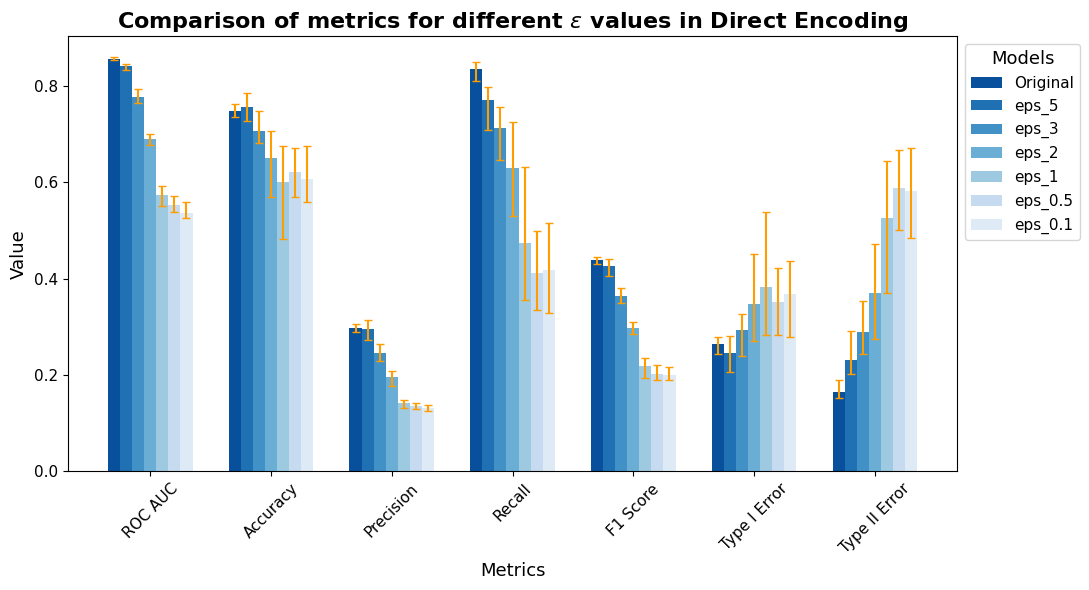

In [21]:
plot_results_with_whiskers(
    results_de_stats,
    title=r"Comparison of metrics for different $\epsilon$ values in Direct Encoding",
    save_path=FIG_DIR / "direct_encoding_results.png",
)
